# What Drives Rental Prices in Airbnb in NYC?

## Objective

This project analyzes Airbnb listings in New York City to identify the key drivers of rental pricing. The goal is to understand how structural features (e.g., location, room type) and behavioral signals (e.g., reviews, availability) influence price. 

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
import os
import kagglehub
import pandas as pd

# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.prop_cycle": cycler(color=['#00695c', 'salmon', 'dodgerblue']),
    'figure.figsize' : [8.0, 3.0],
    'figure.dpi' :250,
    'image.aspect': 7 
})

# 1. Load the data 

## Data Overview
The dataset contains information on Airbnb listings in New York City from 2019, including:

- Location (borough and neighborhood)
- Room type (entire home, private room, shared room)
- Number of reviews
- Availability
- Price

In [34]:
# Download dataset
data_dir = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

# Inspect contents
print(os.listdir(data_dir))

# Load CSV
df = pd.read_csv(os.path.join(data_dir, "AB_NYC_2019.csv"))

['New_York_City_.png', 'AB_NYC_2019.csv']


# 2. Data Cleaning

Several preprocessing steps were applied:

- Removed identifier columns (`id`, `name`, `host_id`, `host_name`) as they do not provide predictive value
- Handled missing values in `reviews_per_month` by filling with 0 (indicating no reviews)
- Removed extreme price outliers to improve model stability

In [36]:
#The `host_name` and `name` columns are removed as they are identifiers and do not provide predictive value for pricing.
df = df.drop(columns=["host_name", "name"])

In [38]:
df.shape

(48895, 14)

The dataset contains approximately 48895 listings. Are there any missing values? 

In [39]:
df.isnull().sum()

id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing values are primarily present in last_review and reviews_per_month. Lets drop those too. 

In [40]:
df = df.drop(columns=["last_review", "reviews_per_month"])

## 2. Distribution of Listings by Borough

In [46]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

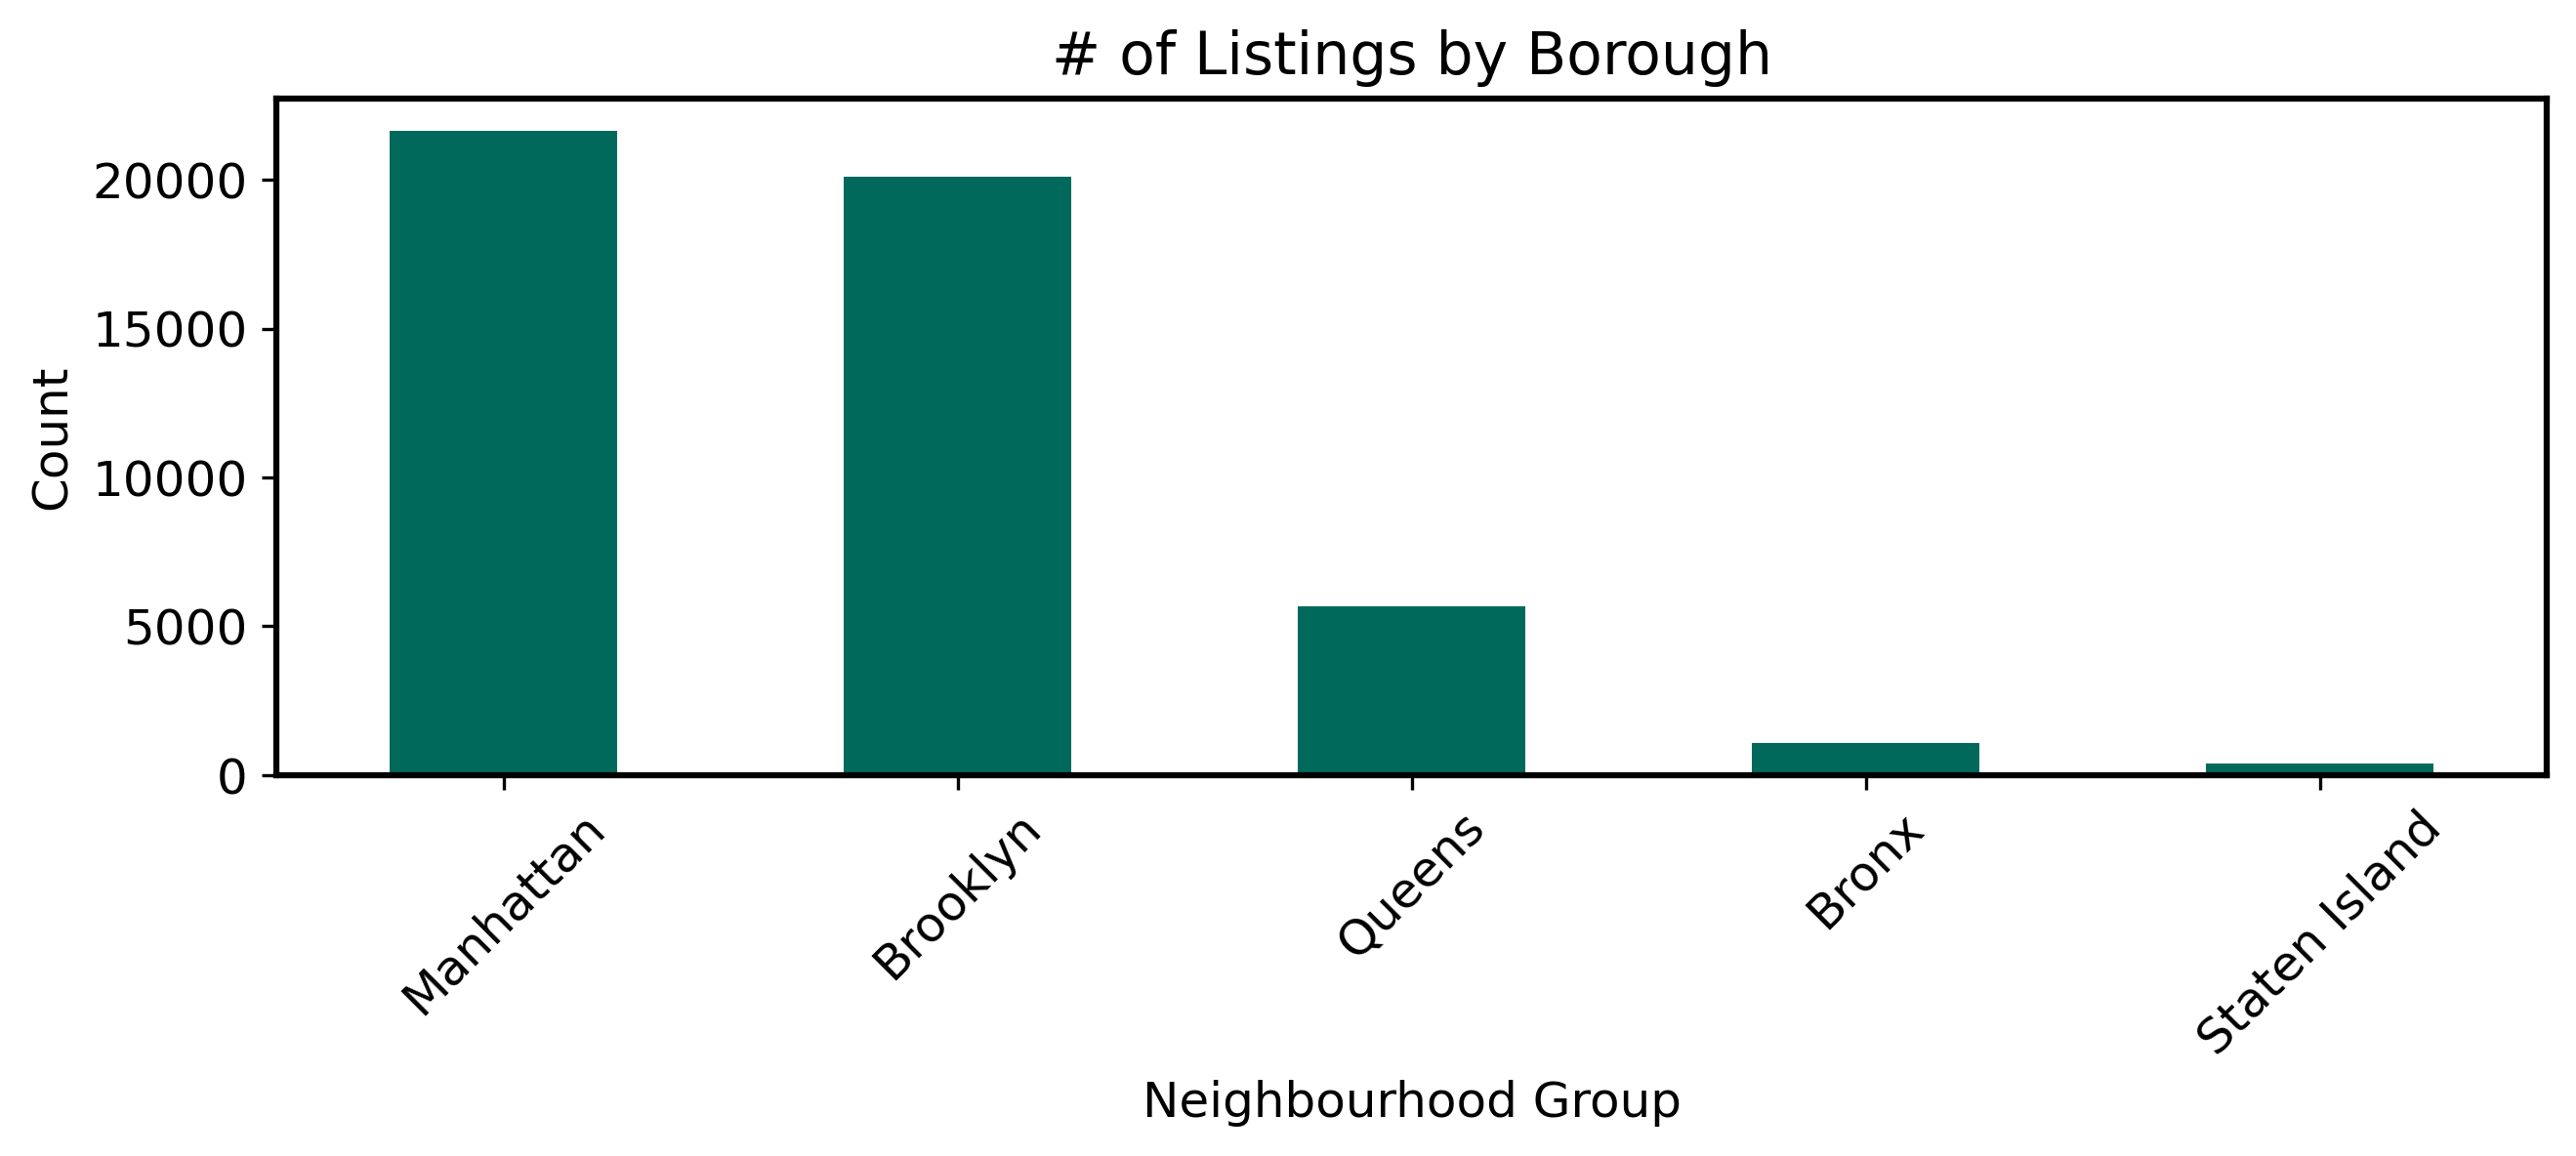

In [49]:
df["neighbourhood_group"].value_counts().plot(kind="bar")

plt.title("# of Listings by Borough")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [48]:
df["neighbourhood_group"].value_counts(normalize=True) * 100

neighbourhood_group
Manhattan        44.301053
Brooklyn         41.116679
Queens           11.588097
Bronx             2.231312
Staten Island     0.762859
Name: proportion, dtype: float64

We see that Manhatten and Brooklyn contains the majority of the listings (>40%). Staten Island is the least represented (<1%). This imbalance is important to consider when modeling, as it may influence feature importance and model predictions.

## 3. Price Distribution By Borough

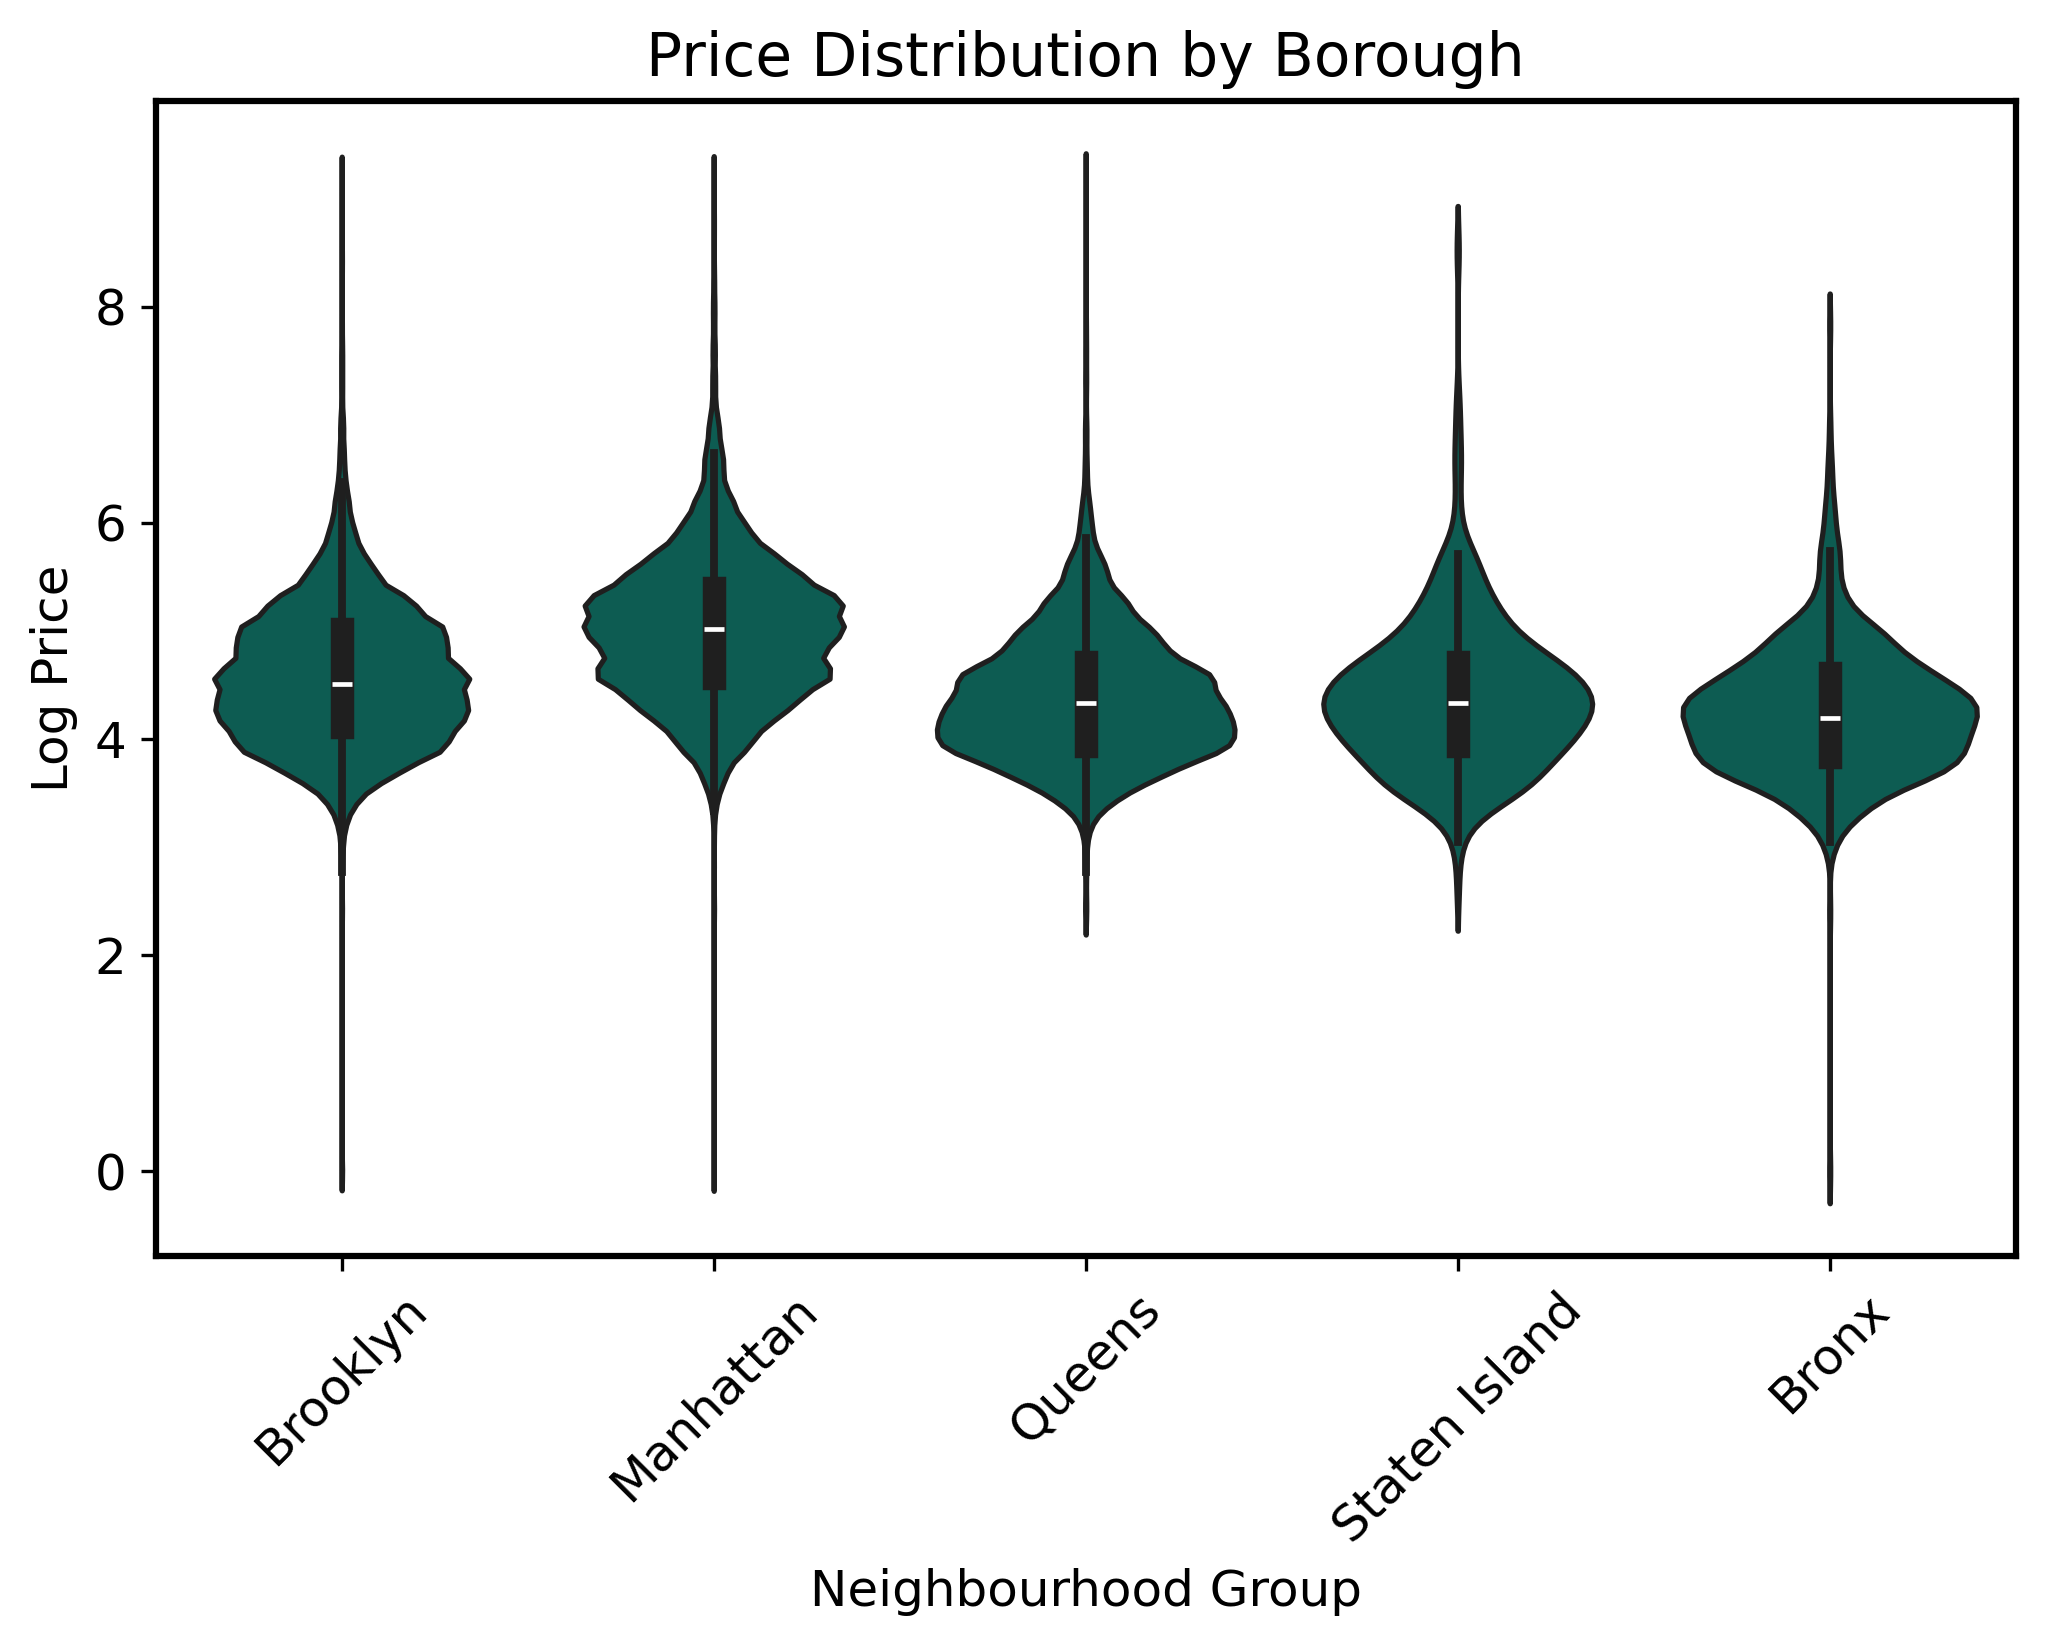

In [66]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="neighbourhood_group",
    y= np.log1p(df["price"]))
plt.title("Price Distribution by Borough")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Log Price")
plt.xticks(rotation=45)

plt.show()

The violin plot reveals clear differences in price distributions across boroughs. Manhattan has the highest median price and a distribution that is consistently shifted upward, indicating that listings are generally more expensive rather than simply driven by a few high-end outliers. Brooklyn follows as the second most expensive borough, while Queens, Staten Island, and the Bronx exhibit lower and more similar price distributions.

This suggests that geographic location sets the baseline for pricing across the platform.

### Room Type Analysis 

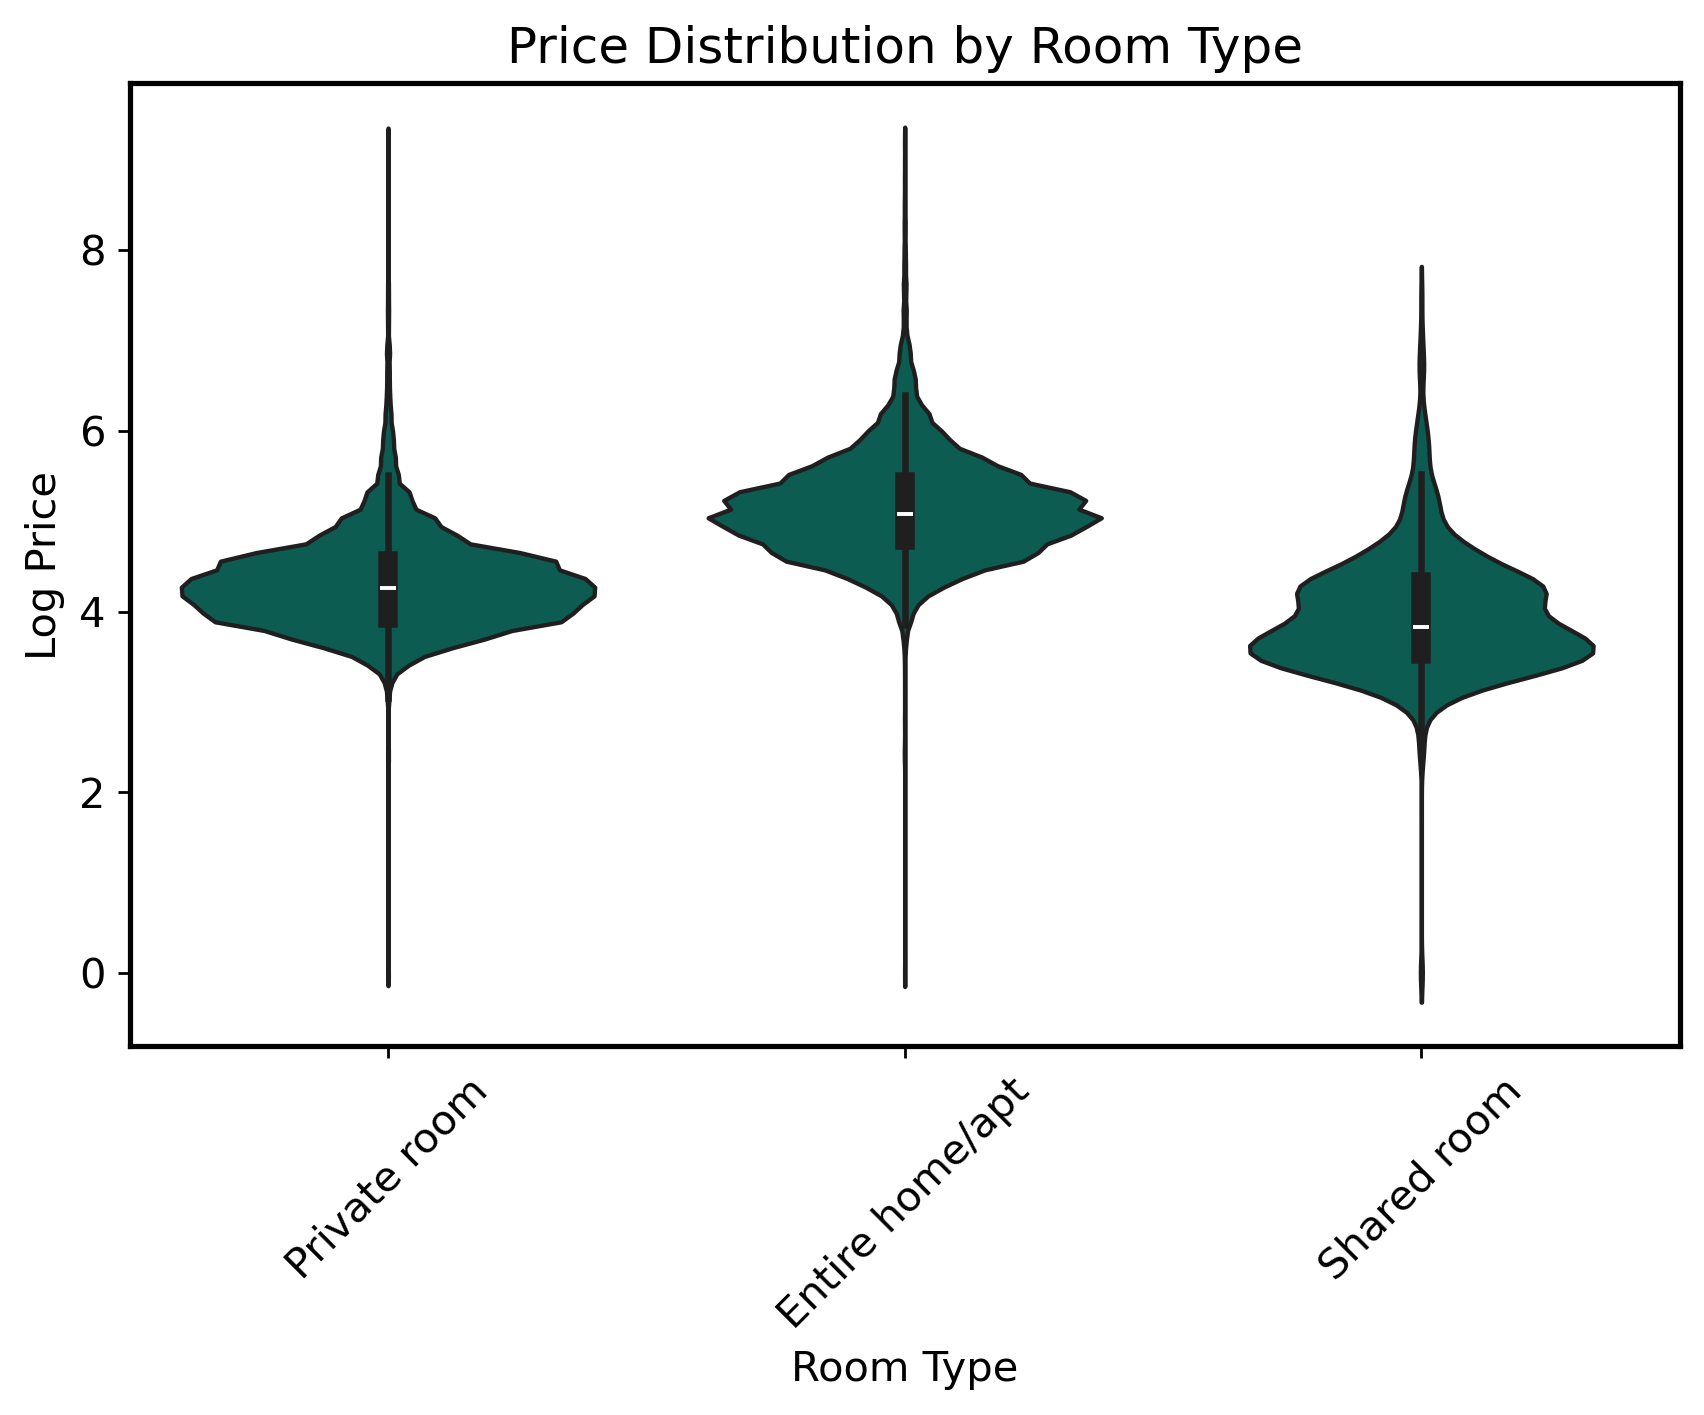

In [72]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="room_type",
    y= np.log1p(df["price"]))
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Log Price")
plt.xticks(rotation=45)

plt.show()

The entire home/apt listings are the most expensive, followed by private rooms, with shared rooms being the least expensive. While there is some overlap between private rooms and entire homes, the distribution for entire homes is consistently shifted higher, indicating a strong pricing premium. 

This suggests that listing type is a major driver of price, likely reflecting differences in privacy and user experience.

### Reviews Analysis

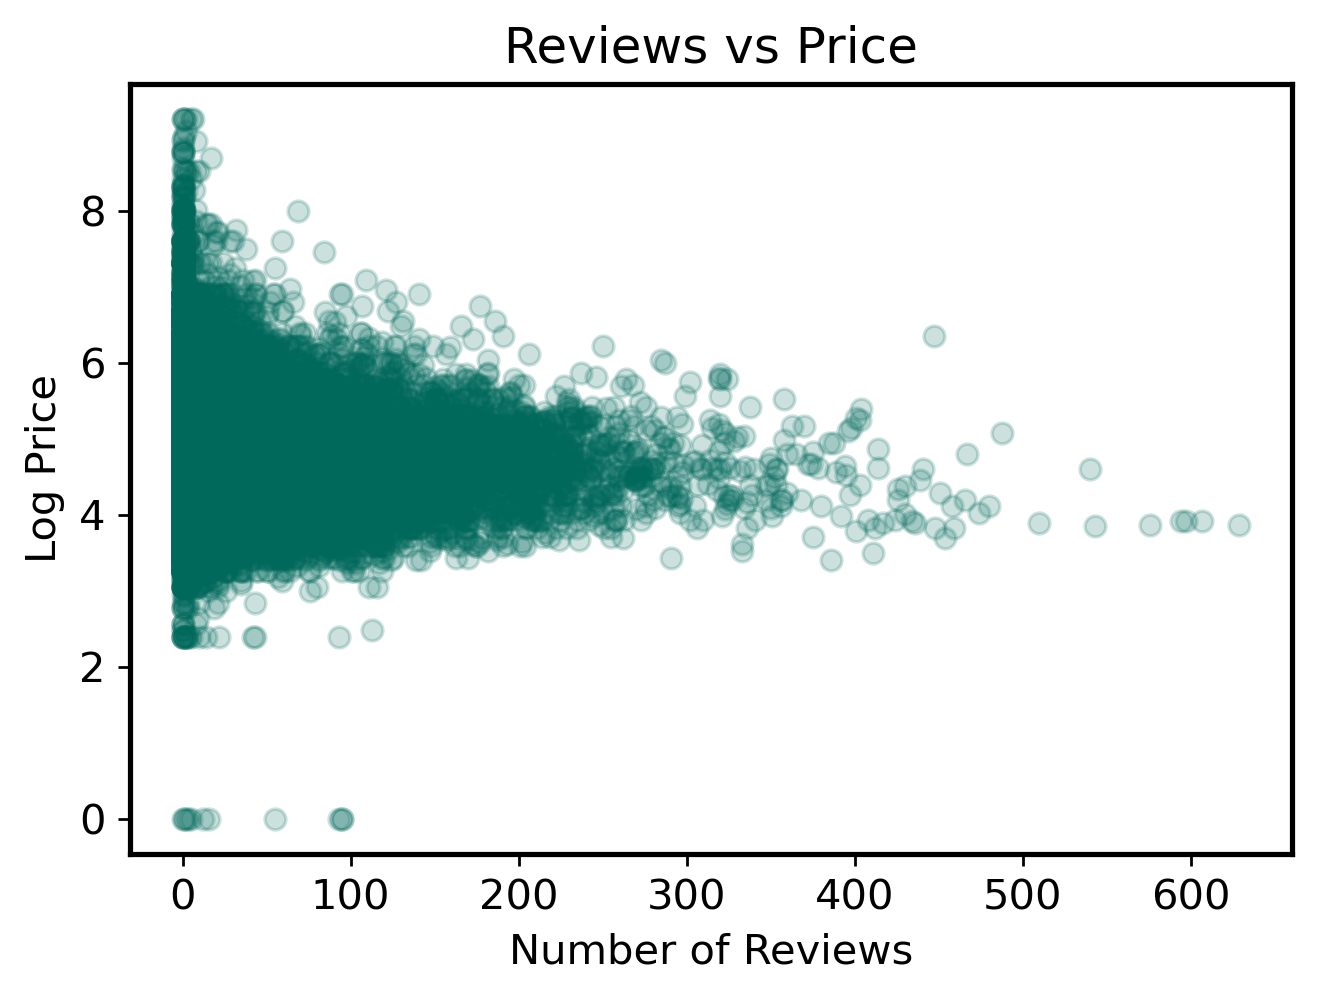

In [75]:
plt.figure(figsize=(6,4))

plt.scatter(df["number_of_reviews"], np.log1p(df["price"]), alpha=0.2)

plt.xlabel("Number of Reviews")
plt.ylabel("Log Price")
plt.title("Reviews vs Price")

plt.show()

This is sort of noisy, so lets group this by number of reviws into bins: low (0-20), medium (20-100), high (100+)

In [76]:
df["review_bin"] = pd.cut(
    df["number_of_reviews"],
    bins=[0, 20, 100, df["number_of_reviews"].max()],
    labels=["Low", "Medium", "High"]
)

Text(0, 0.5, 'Log Price')

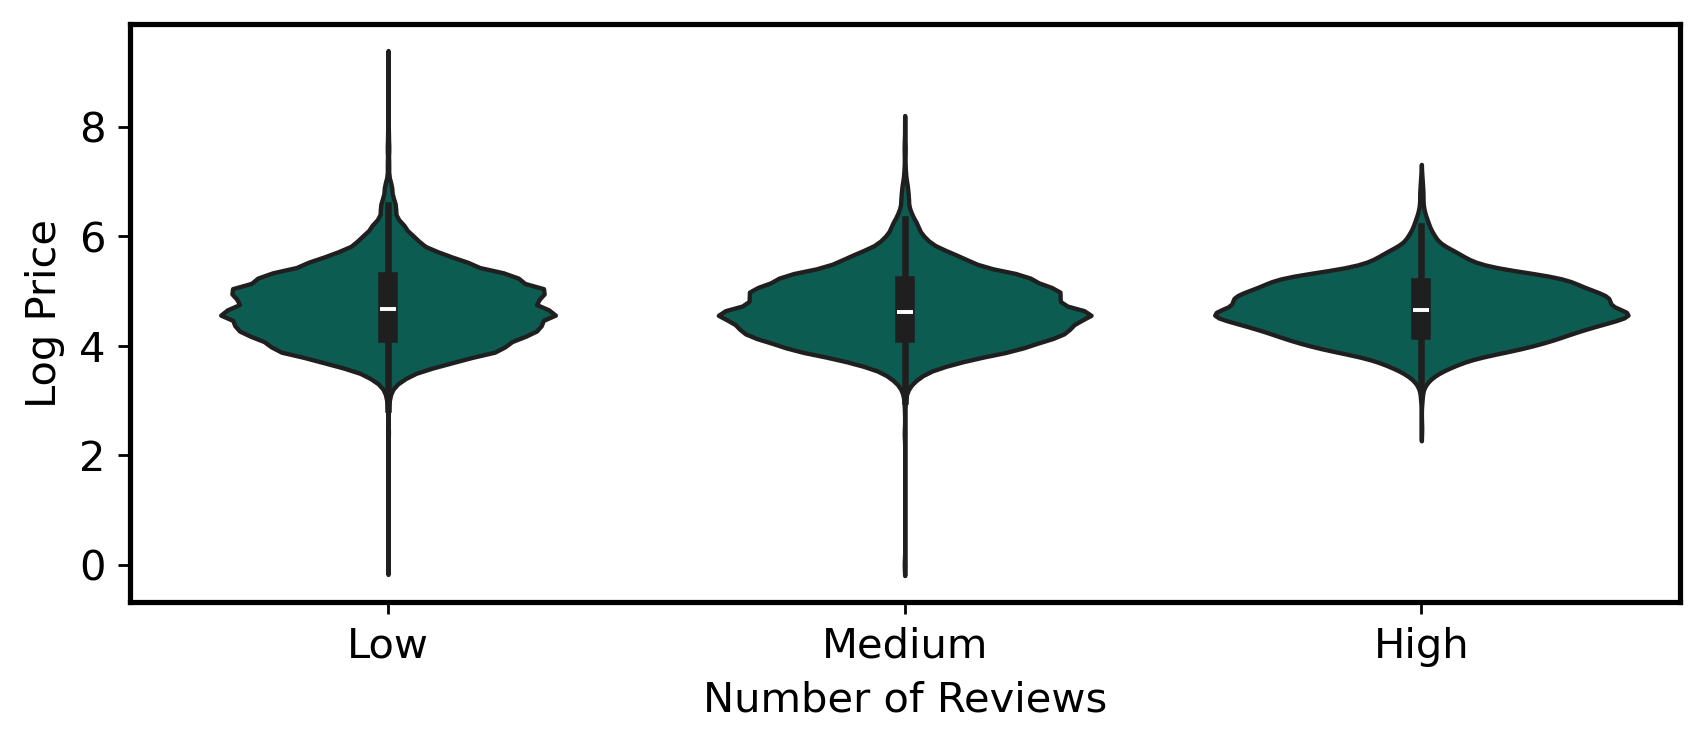

In [79]:
sns.violinplot(
    data=df,
    x="review_bin",
    y = np.log1p(df["price"])
)
plt.xlabel("Number of Reviews")
plt.ylabel("Log Price")


The relationship between number of reviews and price is weak and noisy, with no clear upward trend.

Further analysis shows that listings with a high number of reviews tend to have slightly lower price distributions. This suggests that more frequently booked (and likely more affordable) listings accumulate more reviews over time.

This indicates that reviews are better interpreted as a demand signal rather than a direct driver of pricing.

### Modeling Approach

To quantify the impact of different features on price, two models were used:

- Linear Regression: Provides interpretable coefficients and captures global trends
- Random Forest: Captures nonlinear relationships and feature interactions

The target variable is log(price), and features include location, room type, reviews, availability, and minimum nights.

In [80]:
# Lets prepare features 
features = [
    "neighbourhood_group",
    "room_type",
    "number_of_reviews",
    "availability_365",
    "minimum_nights"
]

In [83]:
# converts categories into numbers using one-hot encoding 
X = pd.get_dummies(df[features], drop_first=True) 
y = np.log1p(df["price"])

## Linear Model

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [97]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear RMSE:", rmse)
print("Linear R2:", r2)

Linear RMSE: 0.4958131444849289
Linear R2: 0.48036973778078385


In [99]:
# What features are important? 
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
4,neighbourhood_group_Manhattan,0.581916
3,neighbourhood_group_Brooklyn,0.262323
5,neighbourhood_group_Queens,0.124730
1,availability_365,0.000717
0,number_of_reviews,-0.000839
2,minimum_nights,-0.001594
6,neighbourhood_group_Staten Island,-0.007772
7,room_type_Private room,-0.773301
8,room_type_Shared room,-1.173519


## Linear Regression Results

The linear model achieves an R² of approximately 0.48, indicating that it explains nearly half of the variation in listing prices.

The model identifies location as the dominant driver of price. Listings in Manhattan are approximately 79% more expensive than the baseline borough, followed by Brooklyn (~30%) and Queens (~13%).

In contrast, variables such as number of reviews and availability have minimal impact on pricing. This suggests that structural features play a much larger role than demand-based signals.

## Random Forest Model

In [103]:
# lets now use a random forest 

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF RMSE: 0.505167265548104
RF R2: 0.4605778633144081


In [104]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)

,feature,importance
7,room_type_Private room,0.373772
1,availability_365,0.218603
0,number_of_reviews,0.140426
2,minimum_nights,0.099047
8,room_type_Shared room,0.077902
4,neighbourhood_group_Manhattan,0.076593
3,neighbourhood_group_Brooklyn,0.008279
5,neighbourhood_group_Queens,0.004084
6,neighbourhood_group_Staten Island,0.001294


## Random Forest Results

The RF model identifies room type as the most important predictor of price, with availability and number of reviews also contributing meaningfully. While the linear model emphasized location as the dominant factor, the Random Forest suggests that room type may play an even stronger role when nonlinear relationships are considered.

# Model Comparision 
Comparing the two models provides a more complete understanding of pricing dynamics.

- The linear model emphasizes location as the primary driver of price
- The Random Forest identifies room type as the strongest feature and highlights the role of behavioral signals

Together, these results suggest that pricing is influenced by two layers:

1. Structural factors (location and room type), which establish baseline pricing
2. Behavioral factors (reviews, availability), which reflect demand and refine pricing within those constraints

This highlights the importance of combining interpretable and flexible models when analyzing real-world systems.

## Conclusion

Rental pricing is primarily driven by structural factors, particularly room type and location. Entire homes and listings in Manhattan command clear price premiums.

Behavioral features such as reviews and availability play a smaller role and appear to reflect demand rather than directly influence pricing.

Comparing linear and Random Forest models shows that pricing is shaped by both baseline structural differences and more complex listing-level dynamics. These findings suggest that rental platforms should prioritize location and listing type in pricing tools, while using behavioral signals to refine recommendations.